# Actividad 1

## Caso 1

Caso 1
Se desea modelar el consumo de energía (y) de una casa en función de:
- 𝑥1: temperatura exterior
- 𝑥2: número de ocupantes
Datos de entrenamiento:

|Temperatura|Personas|Consumo|
|---|---|---|
|20| 2 |30|
|25| 3 |45|
|30| 5 |65|
|35| 4 |60|
|40| 6| 85|

### 1. Ajustar un modelo de regresión lineal y = w1x1 + w2x2 + b minimizando el Error Cuadrático Medio, para ello utilice los métodos de búsqueda cíclica y de Powel.

#### Iteraciones a mano

#### Curvas de nivel

La función MSE tiene 3 variables w1, w2 y b, por lo que no se puede graficar como curvas de nivel.

### 2. Mediante el uso de un lenguaje de programación de solución al problema del ajuste de un modelo de regresión minimizando las métricas:
- MSE
- MAE

#### Definición busqueda ciclica y powell

In [108]:
import numpy as np
def optimizacionCiclica(func, init, directions ,min_delta, max_iter, derivative_func):
    # Algoritmo de optimización cíclica para minimizar una función
    currX = init
    bestX = init
    history = [(currX.copy(), func(*currX))]
    for _ in range(max_iter):
        startX = currX.copy()
        for j in range(len(directions)):
            # Encontrar lambda optima en direccion j
            lambda_opt = optimizacionUnidimensional(currX, directions[j], min_delta, derivative_func)
            # Actualizar currX en la dirección j
            currX = currX + lambda_opt * directions[j]
            # Actualizar bestX si currX es mejor
            if func(*currX) < func(*bestX):
                bestX = currX.copy()
        # Guardar estado al final de la iteración completa
        f_curr = func(*currX)
        f_start = func(*startX)
        history.append((currX.copy(), f_curr))
        if abs(f_curr - f_start) / max(abs(f_start), 1e-12) < min_delta:
            break
    return bestX, history

def metodoPowell(func, init, directions, min_delta, max_iter, derivative_func):
    currX = init.copy()
    history = [(currX.copy(), func(*currX))]

    for _ in range(max_iter):
        x_start = currX.copy()
        f_start = func(*currX)

        # Step 1: line searches along each direction
        for i in range(len(directions)):

            lambda_opt = optimizacionUnidimensional(currX, directions[i], min_delta, derivative_func)
            currX = currX + lambda_opt * directions[i]

        # Step 2: compute new direction (displacement)
        new_direction = currX - x_start

        # Step 3: extra line search along new direction
        lambda_opt = optimizacionUnidimensional(currX, new_direction, min_delta, derivative_func)
        newX = currX + lambda_opt * new_direction

        # Update directions: drop the first direction and add the new direction at the end
        directions = directions[1:] + [new_direction]
        currX = newX
        f_curr = func(*currX)
        history.append((currX.copy(), f_curr))

        if abs(f_curr - f_start) / max(abs(f_start), 1e-12) < min_delta:
            break

    return currX, history

def optimizacionUnidimensional(currX, direction, min_delta, derivative_func):

    def findRoot(func, params, direction, a, b, min_delta):
        # Método de bisección para encontrar la raíz de una función
        while (b - a) / 2 > min_delta:
            midpoint = (a + b) / 2
            if func(params, direction, midpoint) == 0:
                return midpoint
            elif func(params, direction, a) * func(params, direction, midpoint) < 0:
                b = midpoint
            else:
                a = midpoint
        return (a + b) / 2
    # Función de una variable para la optimización unidimensional
    lamda = findRoot(derivative_func, currX, direction, -100, 100, min_delta)
    return lamda

#### Definición funciones a optimizar

In [109]:
# Funciones de error para un modelo lineal con dos características (w1, w2) y un sesgo (b)
def MSE(w1, w2, b): 
    # Función de error cuadrático medio para un modelo lineal 
    return 1/5 * ((30-(w1*20 + w2*2 + b))**2 + (45-(w1*25 + w2*3 + b))**2 + (65-(w1*30 + w2*5 + b))**2 + (60-(w1*35 + w2*4 + b))**2 + (85-(w1*40 + w2*6 + b))**2)

def MAE(w1, w2, b): 
    # Función de error absoluto medio para un modelo lineal 
    return 1/5 * (abs(30-(w1*20 + w2*2 + b)) + abs(45-(w1*25 + w2*3 + b)) + abs(65-(w1*30 + w2*5 + b)) + abs(60-(w1*35 + w2*4 + b)) + abs(85-(w1*40 + w2*6 + b)))

# Derivada de la función f(x+lambda*direction) con respecto a lambda
def derivativeMSE(params, d, lamda):
    w1, w2, b = params

    total = 0

    data = [
        (20, 2, 30),
        (25, 3, 45),
        (30, 5, 65),
        (35, 4, 60),
        (40, 6, 85)
    ]

    for x1, x2, y in data:
        pred = (w1 + lamda*d[0]) * x1 + (w2 + lamda*d[1]) * x2 + (b + lamda*d[2])
        error = y - pred

        # derivative of prediction wrt lambda
        d_pred = d[0]*x1 + d[1]*x2 + d[2]

        total += 2 * error * (-d_pred)

    return total / 5

def derivativeMAE(params, d, lamda):
    w1, w2, b = params

    total = 0

    data = [
        (20, 2, 30),
        (25, 3, 45),
        (30, 5, 65),
        (35, 4, 60),
        (40, 6, 85)
    ]

    for x1, x2, y in data:
        pred = (w1 + lamda*d[0]) * x1 + (w2 + lamda*d[1]) * x2 + (b + lamda*d[2])
        error = y - pred

        # derivative of prediction wrt lambda
        d_pred = d[0]*x1 + d[1]*x2 + d[2]

        total += np.sign(error) * (-d_pred)

    return total / 5


#### Resultados

In [110]:
# Inicialización de los parámetros
init = np.array([0.0, 0.0, 0.0])
directions = [np.array([1.0, 0.0, 0.0]), np.array([0.0, 1.0, 0.0]), np.array([0.0, 0.0, 1.0])]
min_delta = 1e-6
max_iter = 100

print("Optimización cíclica:")
# Optimización para MSE
best_params_MSE_c, hist_MSE_c = optimizacionCiclica(MSE, init, directions, min_delta, max_iter, derivativeMSE)
print("Mejores parámetros para MSE:", best_params_MSE_c)
print("MSE con mejores parámetros:", MSE(*best_params_MSE_c))

# Optimización para MAE
best_params_MAE_c, hist_MAE_c = optimizacionCiclica(MAE, init, directions, min_delta, max_iter, derivativeMAE)
print("Mejores parámetros para MAE:", best_params_MAE_c)
print("MAE con mejores parámetros:", MAE(*best_params_MAE_c))

print("\n-----------------------------------\n")
    
print("Optimización de Powell:")
# Optimización para MSE
best_params_MSE_p, hist_MSE_p = metodoPowell(MSE, init, directions, min_delta, max_iter, derivativeMSE)
print("Mejores parámetros para MSE:", best_params_MSE_p)
print("MSE con mejores parámetros:", MSE(*best_params_MSE_p))

# Optimización para MAE
best_params_MAE_p, hist_MAE_p = metodoPowell(MAE, init, directions, min_delta, max_iter, derivativeMAE)
print("Mejores parámetros para MAE:", best_params_MAE_p)
print("MAE con mejores parámetros:", MAE(*best_params_MAE_p))

Optimización cíclica:
Mejores parámetros para MSE: [  1.28512532   7.37931579 -11.07102334]
MSE con mejores parámetros: 3.180426518157624
Mejores parámetros para MAE: [  1.80000067   4.33332473 -12.99999058]
MAE con mejores parámetros: 2.2666733264923096

-----------------------------------

Optimización de Powell:
Mejores parámetros para MSE: [ 0.84360775  9.22091857 -5.18542668]
MSE con mejores parámetros: 1.2638098156706052
Mejores parámetros para MAE: [  1.7466806    5.01662742 -14.96686679]
MAE con mejores parámetros: 1.9933733580322135


#### Gráficas de convergencia por iteración

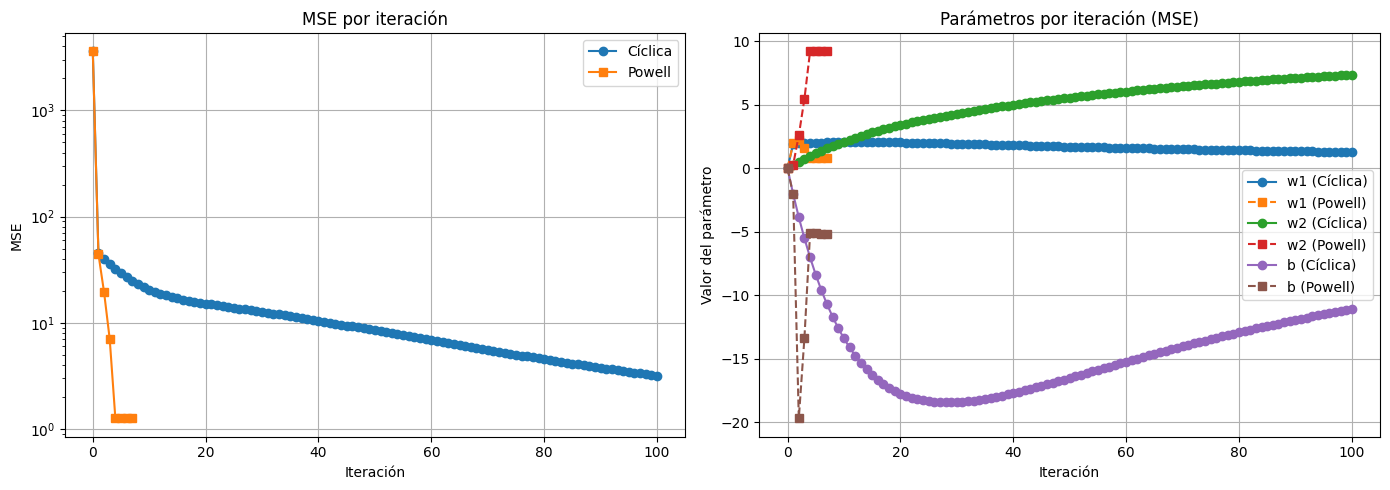

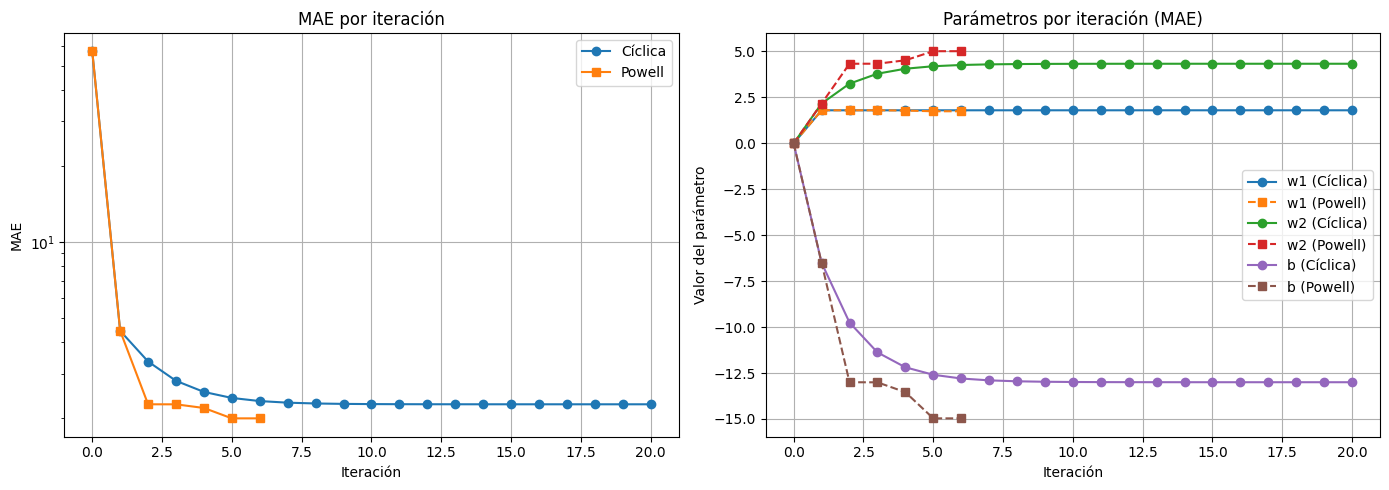

In [111]:
import matplotlib.pyplot as plt

def plot_history(hist_cyclic, hist_powell, metric_name):
    params_c = np.array([h[0] for h in hist_cyclic])
    vals_c = np.array([h[1] for h in hist_cyclic])
    params_p = np.array([h[0] for h in hist_powell])
    vals_p = np.array([h[1] for h in hist_powell])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Valor del objetivo por iteración
    axes[0].plot(vals_c, 'o-', label='Cíclica')
    axes[0].plot(vals_p, 's-', label='Powell')
    axes[0].set_xlabel('Iteración')
    axes[0].set_ylabel(metric_name)
    axes[0].set_title(f'{metric_name} por iteración')
    axes[0].set_yscale('log')
    axes[0].legend()
    axes[0].grid(True)

    # Parámetros por iteración
    labels = ['w1', 'w2', 'b']
    for i, lab in enumerate(labels):
        axes[1].plot(params_c[:, i], 'o-', label=f'{lab} (Cíclica)')
        axes[1].plot(params_p[:, i], 's--', label=f'{lab} (Powell)')
    axes[1].set_xlabel('Iteración')
    axes[1].set_ylabel('Valor del parámetro')
    axes[1].set_title(f'Parámetros por iteración ({metric_name})')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

plot_history(hist_MSE_c, hist_MSE_p, 'MSE')
plot_history(hist_MAE_c, hist_MAE_p, 'MAE')

## Resultados caso 1

Se optimizaron las funciones MSE y MAE con el metodo cilclico y de Powell. Ambos con un delta minimo de 10^-6 y un numero de iteraciones maximo de 100.

hiperparametros:
- delta_minimo = 10^-6
- max_iter = 100

La grafica anterior muestra que para MSE el metodo de Powell converge en menos de 10 iteraciones, comparado al metodo ciclico que no termina de converger llegando a la iteración 100. Para MAE el metodo de Powell converge en 6 iteraciones, mientras que el ciclico en 20. Para ambas funciones objetivo el metodo de Powell alcanza un valor menor en la funcion objetivo. Por esto podemos concluir que Powell converge mas rapido. La siguiente tabla hace un resumen de dichos resultados finales.

|Metodo/función objetivo|Ciclico|Powell|
|---|---|---|
|MSE|3.18|1.26|
|MAE|2.26|1.93|

MSE es una metrica mas sensible a outliers pues cada desviación es elevada al cuadrado, amplificando de manera significativa el impacto de los outliers.

### Comparación MSE y RMSE

Mejores parámetros para RMSE: [ 0.84360775  9.22091857 -5.18542668]
RMSE con mejores parámetros: 1.124192961937854
Mejores parametros para MSE: [ 0.84360775  9.22091857 -5.18542668]
MSE con mejores parámetros: 1.2638098156706052


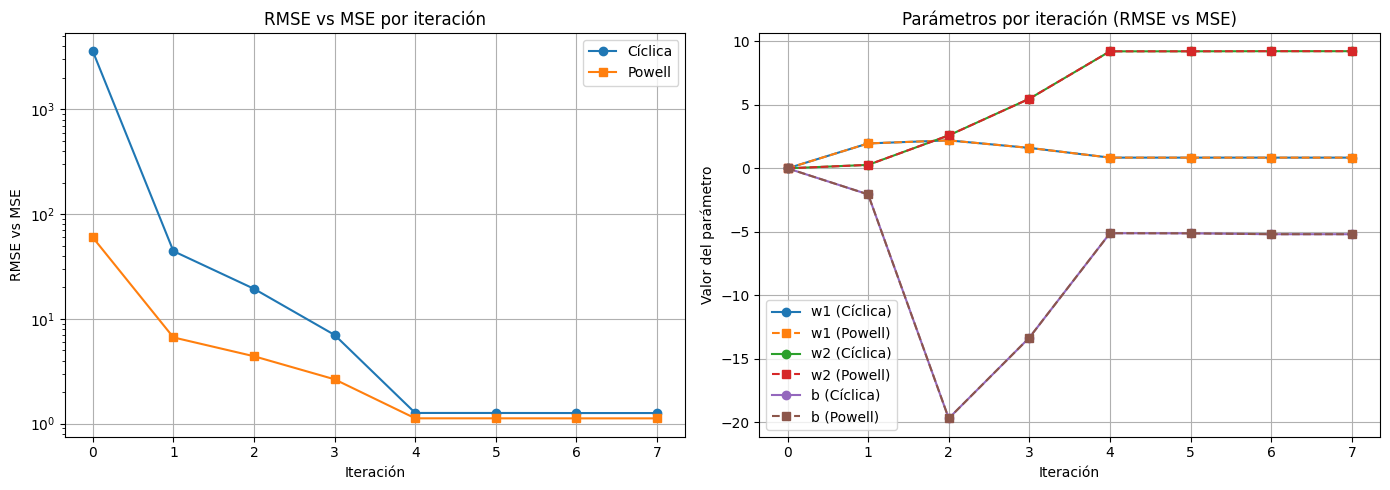

In [112]:
RMSE = lambda w1, w2, b: np.sqrt(MSE(w1, w2, b))
derivativeRMSE = lambda params, d, lamda: derivativeMSE(params, d, lamda) / (2 * RMSE(*params))

# Optimización para RMSE 
best_params_RMSE_p, hist_RMSE_p = metodoPowell(RMSE, init, directions, min_delta, max_iter, derivativeRMSE)
print("Mejores parámetros para RMSE:", best_params_RMSE_p)
print("RMSE con mejores parámetros:", RMSE(*best_params_RMSE_p))

print("Mejores parametros para MSE:", best_params_MSE_p)
print("MSE con mejores parámetros:", MSE(*best_params_MSE_p))

# Comparación de RMSE con MSE
plot_history(hist_MSE_p, hist_RMSE_p, 'RMSE vs MSE')


RMSE no cambia el optimo respecto a MSE, ambos llegan a los mismo parametros finales, esto se puede confirmar mediante la grafica. Ademas, RMSE lo unico que hace es sacar la raiz cuadrada de MSE, por lo que queda claro que para minimizar RMSE hay que minimizar MSE.

En general elegiria el metodo de Powell pues este converge de manera mucho mas eficiente a una solución que suele ser mas cercana al optimo que lo que ofrece la busqueda ciclica.

## Caso 2.
Una empresa desea maximizar los ingresos que obtiene con la exportación de dos productos A y B a un país vecino, cuyas cantidades (en toneladas) están representadas por 𝑥1y 𝑥2, respectivamente.

El precio al que vende el producto A depende de la cantidad de toneladas exportadas del mismo y adopta la expresión 𝑝1 = 100 ― 𝑥1u.m., mientras que el precio por tonelada del segundo producto es 𝑝2 = 50 ― 5𝑥2u.m.

Determinar la cantidad de toneladas que debe exportar de cada producto, teniendo en cuenta que el país vecino no ha puesto ningún límite a la importación de estos dos productos.

- Utilice el método de Powell
- Resuelva a optimalidad (Recomiendo pyomo)

In [113]:
def funcionObjetivo(x1, x2):
    return -((100-x1)*x1 + (50-5*x2)*x2)

def derivativeFuncionObjetivo(params, d, lamda):
    x1, x2 = params
    d_x1, d_x2 = d

    # Derivada de la función objetivo con respecto a lambda
    d_f = 100*d_x1 - 2*(x1 + lamda*d_x1)*d_x1 + 50 * d_x2 - 10*(x2 + lamda*d_x2)*d_x2
    return -(d_f)

# Inicialización de los parámetros
init = np.array([0.0, 0.0])
directions = [np.array([1.0, 0.0]), np.array([0.0, 1.0])]
min_delta = 1e-6
max_iter = 100

print("Optimización de Powell para función objetivo:")
best_params_obj, hist_obj = metodoPowell(funcionObjetivo, init, directions, min_delta, max_iter, derivativeFuncionObjetivo)
print("Mejores parámetros para función objetivo:", best_params_obj)
print("Valor maximo de la función objetivo con mejores parámetros:", -funcionObjetivo(*best_params_obj))


Optimización de Powell para función objetivo:
Mejores parámetros para función objetivo: [49.99999652  5.00000348]
Valor maximo de la función objetivo con mejores parámetros: 2624.9999999999272


In [114]:
import pyomo.environ as pyo
from pyomo.opt import SolverFactory

model = pyo.ConcreteModel()
model.x1 = pyo.Var(domain=pyo.NonNegativeReals)
model.x2 = pyo.Var(domain=pyo.NonNegativeReals)

model.obj = pyo.Objective(expr=funcionObjetivo(model.x1, model.x2), sense=pyo.minimize)

solver = SolverFactory('ipopt')
result = solver.solve(model)

print("Optimización con Pyomo:")
print("Mejores parámetros para función objetivo:", (pyo.value(model.x1), pyo.value(model.x2)))
print("Valor máximo de la función objetivo con mejores parámetros:", -pyo.value(model.obj))

Optimización con Pyomo:
Mejores parámetros para función objetivo: (50.00000000002505, 5.0000000000501155)
Valor máximo de la función objetivo con mejores parámetros: 2625.0


Vemos que el metodo de powell y la solución con pyomo llegan a la misma respues de x1 = 50, x2 = 5 y f* = 2625.
Se debe exportar 50 de producto A y 5 de producto B.

## Caso 3
Una empresa desea maximizar los ingresos que obtiene con la exportación de dos productos 𝐴 y 𝐵 a un país vecino. Las cantidades exportadas (en toneladas) están representadas por 𝑥1 y 𝑥2, respectivamente.

El precio al que vende cada producto depende de la cantidad exportada y presenta un comportamiento no lineal debido a efectos de saturación del mercado.

Datos observados (cantidad–precio):

**Producto A**
|Toneladas| Precio (u.m.)|
|---|---|
|1| 120|
|2 |111|
|4| 104|
|6| 92|
|8 |84|
|10| 70|
|12 |58|

**Producto B**
|Toneladas |Precio (u.m.)|
|---|---|
|1| 80|
|2 |72|
|4 |64|
|6 |53|
|8 |42|
|10| 28|
|12 |14|

Para cada producto:
1. Ajustar el modelo usando:
- Error Cuadrático Medio
- Error absoluto medio
2. Resolver con:
- Método de Powell

Determinar las cantidades 𝑥1y 𝑥2que la empresa debe exportar para maximizar sus
ingresos totales.


### Ajuste de modelos toneladas - precio

In [115]:
datosA = np.array([
    [1, 120],
    [2, 111],
    [4, 104],
    [6, 92],
    [8, 84],
    [10, 70],
    [12, 58]
])
datosB = np.array([
    [1, 80],
    [2, 72],
    [4, 64],
    [6, 53],
    [8, 42],
    [10, 28],
    [12, 14]
])

def MSE_fit(w, b, datos):
    return np.mean((datos[:, 1] - (w * datos[:, 0] + b)) ** 2)

def derivativeMSE_fit(params, d, lamda, datos):
    w, b = params
    d_w, d_b = d

    total = 0
    for x, y in datos:
        pred = (w + lamda*d_w) * x + (b + lamda*d_b)
        error = y - pred
        d_pred = d_w * x + d_b
        total += 2 * error * (-d_pred)

    return total / len(datos)

def MAE_fit(w, b, datos):
    return np.mean(np.abs(datos[:, 1] - (w * datos[:, 0] + b)))

def derivativeMAE_fit(params, d, lamda, datos):
    w, b = params
    d_w, d_b = d

    total = 0
    for x, y in datos:
        pred = (w + lamda*d_w) * x + (b + lamda*d_b)
        error = y - pred
        d_pred = d_w * x + d_b
        total += np.sign(error) * (-d_pred)

    return total / len(datos)

# Inicialización local para ajustes 2D (w, b)
init_fit = np.array([0.0, 0.0])
directions_fit = [np.array([1.0, 0.0]), np.array([0.0, 1.0])]

# Optimización para datos A
best_params_A, hist_A = metodoPowell(lambda w, b: MSE_fit(w, b, datosA), init_fit, directions_fit, min_delta, max_iter, lambda params, d, lamda: derivativeMSE_fit(params, d, lamda, datosA))
print("Mejores parámetros para datos A:", best_params_A)
print("MSE con mejores parámetros para datos A:", MSE_fit(*best_params_A, datosA))

best_params_A_MAE, hist_A_MAE = metodoPowell(lambda w, b: MAE_fit(w, b, datosA), init_fit, directions_fit, min_delta, max_iter, lambda params, d, lamda: derivativeMAE_fit(params, d, lamda, datosA))
print("Mejores parámetros para MAE en datos A:", best_params_A_MAE)
print("MAE con mejores parámetros para datos A:", MAE_fit(*best_params_A_MAE, datosA))

print("\n-----------------------------------\n")

# Optimización para datos B
best_params_B, hist_B = metodoPowell(lambda w, b: MSE_fit(w, b, datosB), init_fit, directions_fit, min_delta, max_iter, lambda params, d, lamda: derivativeMSE_fit(params, d, lamda, datosB))
print("Mejores parámetros para datos B:", best_params_B)
print("MSE con mejores parámetros para datos B:", MSE_fit(*best_params_B, datosB))
best_params_B_MAE, hist_B_MAE = metodoPowell(lambda w, b: MAE_fit(w, b, datosB), init_fit, directions_fit, min_delta, max_iter, lambda params, d, lamda: derivativeMAE_fit(params, d, lamda, datosB))
print("Mejores parámetros para MAE en datos B:", best_params_B_MAE)
print("MAE con mejores parámetros para datos B:", MAE_fit(*best_params_B_MAE, datosB))

Mejores parámetros para datos A: [ -5.42634498 124.61897518]
MSE con mejores parámetros para datos A: 2.80959125860673
Mejores parámetros para MAE en datos A: [ -5.55555562 125.55555562]
MAE con mejores parámetros para datos A: 1.158730176443265

-----------------------------------

Mejores parámetros para datos B: [-5.81444796 86.14589507]
MSE con mejores parámetros para datos B: 3.136584378796153
Mejores parámetros para MAE en datos B: [-5.77768269 85.77682627]
MAE con mejores parámetros para datos B: 1.4763944996194647


### Optimización cantidad de toneladas

In [116]:


def funcionObjetivo2(A, B):
    return -((best_params_A[0]*A + best_params_A[1])*A + (best_params_B[0]*B + best_params_B[1])*B)

def derivativeFuncionObjetivo2(params, d, lamda):
    A, B = params
    d_A, d_B = d

    # Derivada de la función objetivo con respecto a lambda
    d_f = 2*best_params_A[0]*(A + lamda*d_A)*d_A + best_params_A[1]*d_A + 2*best_params_B[0]*(B + lamda*d_B)*d_B + best_params_B[1]*d_B
    return -(d_f)

best_params_obj2, hist_obj2 = metodoPowell(funcionObjetivo2, init_fit, directions_fit, min_delta, max_iter, derivativeFuncionObjetivo2)
print("Mejores parámetros para función objetivo 2:", best_params_obj2)
print("Valor maximo de la función objetivo 2 con mejores parámetros:", -funcionObjetivo2(*best_params_obj2))


Mejores parámetros para función objetivo 2: [11.4827759   7.40791479]
Valor maximo de la función objetivo 2 con mejores parámetros: 1034.5665194548662
